<a href="https://colab.research.google.com/github/vishalmahor886/basic_ML_code/blob/main/handling_missing_value(Cate).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Missing value handling for categorical features

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day37-handling-missing-categorical-data/train.csv"

df = pd.read_csv(url)


In [ ]:
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1282,1283,20,RL,61.0,8800,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,150500
509,510,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2009,WD,Normal,124500
802,803,60,RL,63.0,8199,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2008,WD,Normal,189000
689,690,120,RL,61.0,7577,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,194700
101,102,60,RL,77.0,9206,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,178000


In [ ]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
df = df[['GarageQual', 'FireplaceQu', 'SalePrice']]

In [ ]:
df.sample(5)

,GarageQual,FireplaceQu,SalePrice
18,TA,NaN,159000
309,TA,Ex,360000
224,TA,Ex,386250
551,TA,NaN,112500
785,TA,Gd,161500


In [ ]:
df.isnull().mean()*100

,0
GarageQual,5.547945
FireplaceQu,47.260274
SalePrice,0.000000


<Axes: xlabel='GarageQual'>

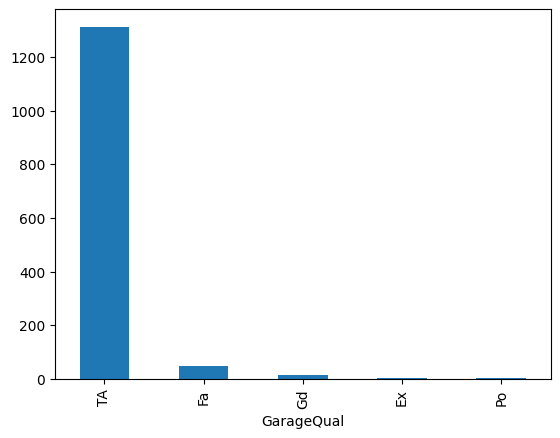

In [ ]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()

In [ ]:
df['GarageQual'].mode()

,GarageQual
0,TA


<Axes: xlabel='FireplaceQu'>

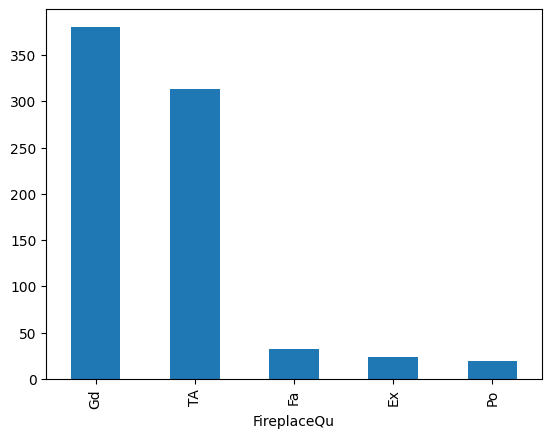

In [ ]:
df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()

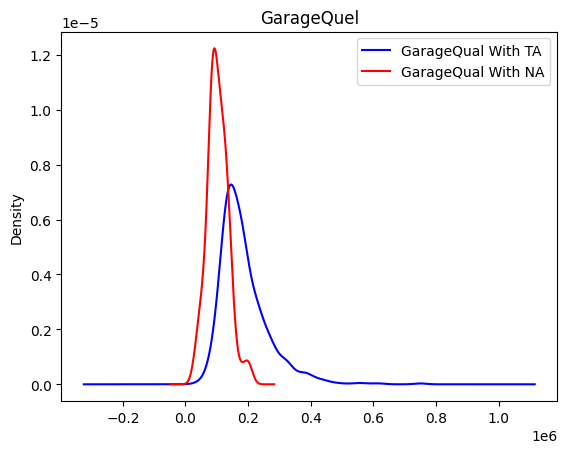

In [ ]:
fig = plt.figure()
plt.subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', color='blue')

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', color='red')
plt.legend(['GarageQual With TA', 'GarageQual With NA'])
plt.title('GarageQuel')

plt.show()

In [ ]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [ ]:
df['GarageQual'].fillna(value='TA', inplace=True)

/tmp/ipython-input-443899175.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna(value='TA', inplace=True)


In [ ]:
df.isnull().mean()*100

,0
GarageQual,0.000000
FireplaceQu,47.260274
SalePrice,0.000000


<Axes: xlabel='GarageQual'>

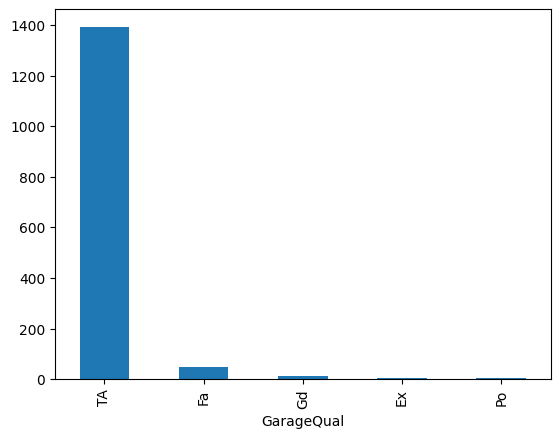

In [ ]:
df['GarageQual'].value_counts().plot.bar()

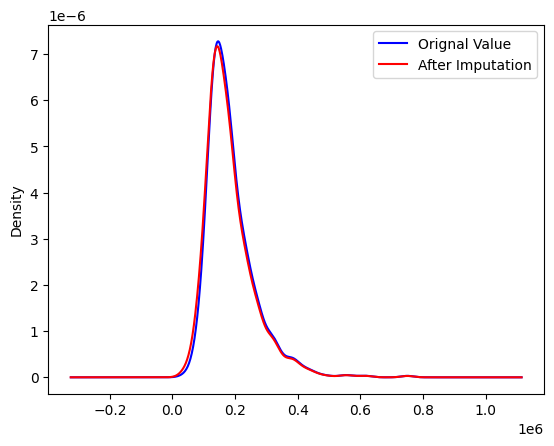

In [ ]:
fig = plt.figure()
plt.subplot(111)
temp.plot(kind='kde', color='blue')
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', color='red')
plt.legend(['Orignal Value', 'After Imputation'])
plt.show()

<Axes: xlabel='FireplaceQu'>

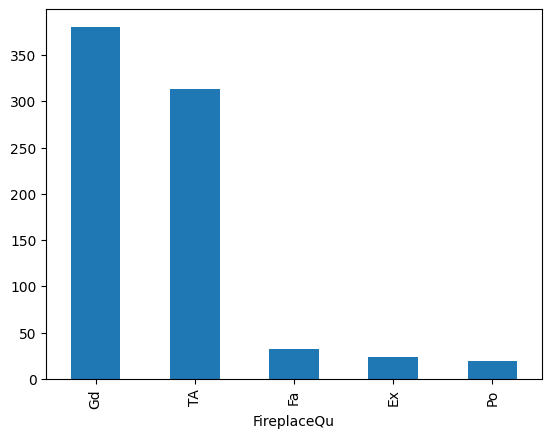

In [ ]:
df['FireplaceQu'].value_counts().plot.bar()

In [ ]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


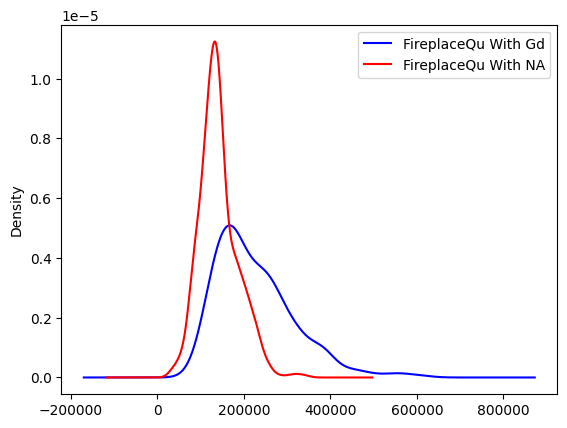

In [ ]:
fig = plt.figure()
plt.subplot(111)
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', color="blue")
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', color='red')
plt.legend(['FireplaceQu With Gd', 'FireplaceQu With NA'])
plt.show()

In [ ]:
## replace with mode()
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [ ]:
df['FireplaceQu'].fillna(value='Gd', inplace=True)

/tmp/ipython-input-2413778175.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna(value='Gd', inplace=True)


In [ ]:
df.isnull().mean()*100

,0
GarageQual,0.0
FireplaceQu,0.0
SalePrice,0.0


<Axes: xlabel='FireplaceQu'>

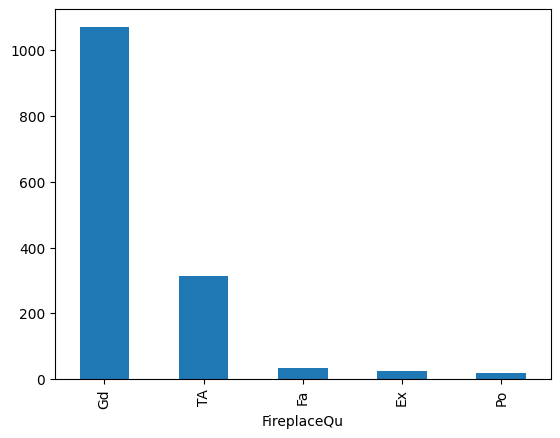

In [ ]:
## bar chart
df['FireplaceQu'].value_counts().plot.bar()

/tmp/ipython-input-3965149640.py:8: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Orignal Value', 'After Imputation')


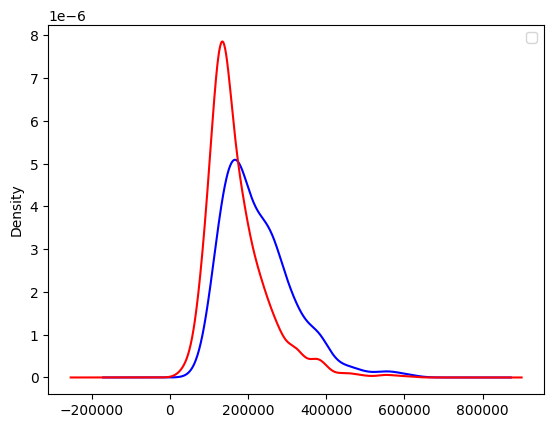

In [ ]:
fig = plt.figure()
plt.subplot(111)

temp.plot(kind='kde', color='blue')

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', color='red')

plt.legend('Orignal Value', 'After Imputation')
plt.show()

In [ ]:

## using sklearn

from sklearn.model_selection import train_test_split

In [ ]:
df1 = pd.read_csv(url, usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [ ]:
x=df1.drop(columns='SalePrice')
y=df1['SalePrice']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [ ]:
# import SimpleImputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')

In [ ]:
imputer.fit(x_train)

SimpleImputer(strategy='most_frequent')

In [ ]:
x_train = imputer.transform(x_train)
x_test = imputer.transform(x_test)

In [ ]:
imputer.statistics_



array(['Gd', 'TA'], dtype=object)

# Add Missing at place of NA

In [ ]:
new_df = df1 = pd.read_csv(url, usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [ ]:
# USing pandas

new_df.fillna(value='missing', inplace=True)

new_df.isnull().mean()*100



,0
FireplaceQu,0.0
GarageQual,0.0
SalePrice,0.0


In [ ]:
## Using SKlearn
x = new_df.drop(columns='SalePrice')
y = new_df['SalePrice']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=0)

In [ ]:
imputer = SimpleImputer(strategy='constant', fill_value='missing')

In [ ]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [ ]:
imputer.statistics_

array(['missing', 'missing'], dtype=object)